# GREENFUEL LCA — Biomass to Bio-oil (updated)
**Phase 1 | Single biomass scenario | Cradle-to-grave | FU = 1 MJ usable bio-oil (marine fuel)**

All yield parameters are loaded automatically from the most recent `yield_results_*/yield_results.xlsx`.

**Only edit Section 1 (USER CONFIG).** Then run all cells top to bottom.

---

In [121]:
import bw2data as bd
import bw2calc as bc
import bw2analyzer as ba
import pandas as pd
import nbconvert
import numpy as np
from tqdm import tqdm
import bw2io as bi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [122]:
# ===========================================================================
# SECTION 1 — USER CONFIG  (the only cell you need to edit)
# ===========================================================================

# ── Brightway project and database names ────────────────────────────────────
# Not sure which names to use? Run the DB Check cell below first.
BW_PROJECT   = 'GREENFUEL_LCA_WOOD'              # <-- your Brightway project name
ECOINVENT_DB = 'ecoinvent-3.12-cutoff'  # <-- your ecoinvent database name
BIOSPHERE_DB = 'ecoinvent-3.12-biosphere'                # usually unchanged

# ── Which biomass to model ───────────────────────────────────────────────────
# Partial, case-insensitive match against the 'subcategory' column in yield_results.xlsx.
# Examples: 'Oak wood1', 'beech', 'spruce', 'miscanthus', 'wheat straw'
BIOMASS_NAME = 'Grape seeds 1'  # <-- your biomass of choice
# These are your choices at the moment: 
# Oak wood1,
# Branches and leaves from poplar tree 3
#  Poplar 4
# Walnut shell 1
# peanut hulls
# Olive kernels
# fir mill waste
# Maple fruit
# Grape seeds 1


# ── Transport distances [km] ─────────────────────────────────────────────────
d1 = 50    # feedstock  → pyrolysis plant
d2 = 100   # bio-oil    → port / end use
d3 = 150   # bio-char   → soil amendment site

# ── Pyrolysis energy intensities ─────────────────────────────────────────────
# Defaults: Bridgwater (2012), fast pyrolysis.
# Replace with your own literature values when available.
k_el = 0.15   # electricity  [kWh / kg dry biomass]
k_th = 0.75   # process heat [MJ  / kg dry biomass]

# ── Monte Carlo ──────────────────────────────────────────────────────────────
MC_ITERATIONS = 1000   # increase to 500-1000 for publication-quality results

# ── Output ───────────────────────────────────────────────────────────────────
import os as _os
OUTPUT_CSV = _os.path.join(_os.path.dirname(_os.path.abspath('__file__')),
                           f'lca_results_{BIOMASS_NAME}.csv')

# True  = keep biomass-specific foreground DBs (recommended for traceability)
# False = delete the current run DB at the end
KEEP_FOREGROUND = True


---
### DB Check — run this cell once to find your project and database names
Look for the row with the largest number of activities (> 10 000).
Copy that project name into `BW_PROJECT` and the database name into `ECOINVENT_DB` above.

In [123]:
import bw2data as _bd
print(f'{"Project":<28} {"Database":<45} {"Activities":>12}  Note')
print('-' * 100)
for _p in _bd.projects:
    _bd.projects.set_current(_p.name)
    for _db_name in _bd.databases:
        _n = len(_bd.Database(_db_name))
        _note = '  <-- use this as ECOINVENT_DB' if _n > 5000 else ''
        print(f'{_p.name:<28} {_db_name:<45} {_n:>12}{_note}')

Project                      Database                                        Activities  Note
----------------------------------------------------------------------------------------------------
default                      biosphere3                                            4718
DTU_project2                 biosphere3                                            4718
DTU_project2                 ecoinvent-3.9.1-cutoff                               21238  <-- use this as ECOINVENT_DB
DTU_project2                 ecoinvent-3.9.1-cutoff - remind - SSP1-Base          28551  <-- use this as ECOINVENT_DB
DTU_project2                 ecoinvent-3.9.1-cutoff - remind - SSP1-NDC           28564  <-- use this as ECOINVENT_DB
DTU_project2                 ecoinvent-3.9.1-cutoff - remind - SSP1-NPi           28564  <-- use this as ECOINVENT_DB
DTU_project2                 ecoinvent-3.9.1-cutoff - remind - SSP1-PkBudg1150        28564  <-- use this as ECOINVENT_DB
DTU_project2                 ecoinv

---
## ENGINE — do not edit cells below this line
---

In [124]:
# ── Imports ─────────────────────────────────────────────────────────────────
import bw2data as bd
import bw2calc as bc
import pandas as pd
import numpy as np
import glob, os
from tqdm import tqdm

print('bw2data :', bd.__version__)
print('bw2calc :', bc.__version__)
print('Imports OK')

bw2data : 4.6.2
bw2calc : 2.4.0
Imports OK


In [125]:
# Step 1: Find the most recent yield_results_* folder
from pathlib import Path as _Path

# Anchor on the project folder so the notebook runs from any location.
_PROJECT_ROOT = next(
    (d for d in [_Path.cwd(), *_Path.cwd().parents] if (d / 'BIOMASS_to_BIO-OIL').is_dir()),
    _Path.cwd(),
)
YIELD_BASE = str(_PROJECT_ROOT / 'BIOMASS_to_BIO-OIL')

folders = sorted(glob.glob(os.path.join(YIELD_BASE, 'yield_results_*')))
if not folders:
    raise FileNotFoundError(f'No yield_results_* folders found in: {YIELD_BASE}')

latest = folders[-1]
yield_file = os.path.join(latest, 'yield_results.xlsx')

print('Folders found:')
for f in folders:
    tag = '  <-- USING THIS' if f == latest else ''
    print(f'  {os.path.basename(f)}{tag}')

print(f'\nReading: {yield_file}')
df_all = pd.read_excel(yield_file, sheet_name='results')
print(f'Loaded {len(df_all)} rows | {df_all["feedstock_id"].nunique()} unique feedstocks')

Folders found:
  yield_results_20260625_094940  <-- USING THIS

Reading: c:\Users\s233432\OneDrive - Danmarks Tekniske Universitet\Skrivebord\GREENFUEL_PROJECT\BIOMASS_to_BIO-OIL\yield_results_20260625_094940\yield_results.xlsx
Loaded 6487 rows | 499 unique feedstocks


In [126]:
# Step 1.5: Load process config file
from pathlib import Path as _Path

# Config workbook sits next to this notebook (LCA_PROJECT/Project biomass/).
CONFIG_PATH = str(_Path.cwd() / 'LCA_process_config.xlsx')

df_biomass_cfg = pd.read_excel(CONFIG_PATH, sheet_name='Biomass_Selection')
df_lci_map     = pd.read_excel(CONFIG_PATH, sheet_name='LCI_Mapping')

print(f'Config loaded: {len(df_biomass_cfg)} biomass entries | {len(df_lci_map)} process rows')
print(f'Categories covered: {sorted(df_lci_map["category"].unique())}')

Config loaded: 9 biomass entries | 57 process rows
Categories covered: ['Agricultural wastes', 'Residues and wastes', 'Wood']


In [127]:
# ── Step 2: Select biomass and extract all parameters ────────────────────────
# Columns used (confirmed in yield_results.xlsx):
#   oil_yield_kg_per_kg          -> x (bio-oil yield, as-received basis)
#   bio_oil_hhv_mj_per_kg        -> T (HHV of produced bio-oil)
#   temperature_c                -> T_py (optimal pyrolysis temperature)
#   kg_biomass_per_mj_bio_oil_hhv -> y (kg biomass per FU, pre-computed)
#   char_yield_kg_per_kg         -> used to compute c
#   gas_yield_kg_per_kg          -> used to compute g

mask_name = df_all['subcategory'].str.lower().str.contains(BIOMASS_NAME.lower(), na=False)
mask_ok   = df_all['acceptance_flag'].isin(['PASS', 'ACCEPT'])
candidates = df_all.loc[mask_name & mask_ok].copy()

if candidates.empty:
    # Relax acceptance filter
    candidates = df_all.loc[mask_name].copy()
    if not candidates.empty:
        print('WARNING: no PASS/ACCEPT rows — using all acceptance levels.')

if candidates.empty:
    available = sorted(df_all['subcategory'].dropna().unique().tolist())
    print(f'No rows match BIOMASS_NAME="{BIOMASS_NAME}"')
    print('Available subcategory names:')
    for n in available:
        print(f'  {n}')
    raise ValueError('Update BIOMASS_NAME in the USER CONFIG cell.')

# Pick the row (temperature) with the highest oil yield
peak = candidates.loc[candidates['oil_yield_kg_per_kg'].idxmax()]

# ── Parameters.md notation ───────────────────────────────────────────────────
x    = float(peak['oil_yield_kg_per_kg']) * 100          # bio-oil yield [%]
T    = float(peak['bio_oil_hhv_mj_per_kg'])              # HHV of produced bio-oil [MJ/kg]
T_py = float(peak['temperature_c'])                      # optimal pyrolysis temperature [°C]

# y = kg biomass per FU  (pre-computed in yield_results; fall back if column missing)
_y_col = peak.get('kg_biomass_per_mj_bio_oil_hhv', None)
if _y_col is not None and not pd.isna(_y_col):
    y = float(_y_col)
else:
    y = 1.0 / (float(peak['oil_yield_kg_per_kg']) * T)
    print('NOTE: kg_biomass_per_mj_bio_oil_hhv not found; computed as 1/(yield × HHV)')

z    = 1.0 / T                                           # bio-oil per FU [kg/FU]
c    = float(peak['char_yield_kg_per_kg']) * y           # bio-char per FU [kg/FU]
g    = float(peak['gas_yield_kg_per_kg'])  * y           # syngas per FU [kg/FU]
w    = 1e6                                               # energy [J/FU] = 1 MJ by definition
MC   = 0.0                                               # feedstock moisture [wt% as-received]; set from config below

# Transport loads [tonne-km / FU]
tkm1 = d1 * (y / 1000)   # feedstock
tkm2 = d2 * (z / 1000)   # bio-oil
tkm3 = d3 * (c / 1000)   # bio-char

print(f'Biomass matched : {peak["subcategory"]}  ({peak["category"]})')
print(f'Peak temperature: {T_py:.0f} °C     acceptance: {peak.get("acceptance_flag", "n/a")}')
print()
print(f'  x    = {x:.2f} %         (bio-oil yield, as-received)')
print(f'  T    = {T:.3f} MJ/kg    (HHV of produced bio-oil)')
print(f'  T_py = {T_py:.0f} °C')
print(f'  y    = {y:.5f} kg/FU   (biomass required per 1 MJ bio-oil)')
print(f'  z    = {z:.5f} kg/FU   (bio-oil mass produced per FU)')
print(f'  c    = {c:.5f} kg/FU   (bio-char mass produced per FU, incl. ash)')
print(f'  g    = {g:.5f} kg/FU   (syngas mass produced per FU)')
print(f'  w    = {w:.0f} J/FU     (energy content of 1 MJ bio-oil)')
print (f' bio-char and syngas will not be included in the FU,\n but their yields are important for co-product credits and energy balance calculations,\n if they were included in the LCI, we could broaden the system boundary\n and account for more benefits with the biomass than for now.')
print()
print(f'  tkm1 = {tkm1:.6f} tonne-km/FU  (feedstock, d1={d1} km)')
print(f'  tkm2 = {tkm2:.6f} tonne-km/FU  (bio-oil,   d2={d2} km)')
print(f'  tkm3 = {tkm3:.6f} tonne-km/FU  (bio-char,  d3={d3} km)')

# ── Override d1/d2/d3/k_el/k_th from config if biomass is listed there ───────
cfg_match = df_biomass_cfg[
    df_biomass_cfg['subcategory'].str.lower() == BIOMASS_NAME.lower()
]
if not cfg_match.empty:
    cfg_row = cfg_match.iloc[0]
    d1   = float(cfg_row['d1_km_feedstock'])
    d2   = float(cfg_row['d2_km_biooil'])
    d3   = float(cfg_row['d3_km_char'])
    k_el = float(cfg_row['k_el_kwh_per_kg'])
    k_th = float(cfg_row['k_th_mj_per_kg'])
    MC   = float(cfg_row['feedstock_moisture_pct_ar']) if pd.notna(cfg_row.get('feedstock_moisture_pct_ar')) else 0.0
    tkm1 = d1 * (y / 1000)
    tkm2 = d2 * (z / 1000)
    tkm3 = d3 * (c / 1000)
    print(f'Category used from excel config file: {cfg_row["category"]}')
    print(f'Config override applied for "{BIOMASS_NAME}": '
          f'd1={d1}, d2={d2}, d3={d3}, k_el={k_el}, k_th={k_th}')
    
else:
    print(f'"{BIOMASS_NAME}" not in Biomass_Selection — using USER CONFIG values for d1/d2/d3/k_el/k_th')

Biomass matched : Grape seeds 1  (Residues and wastes)
Peak temperature: 375 °C     acceptance: PASS

  x    = 65.26 %         (bio-oil yield, as-received)
  T    = 35.158 MJ/kg    (HHV of produced bio-oil)
  T_py = 375 °C
  y    = 0.04358 kg/FU   (biomass required per 1 MJ bio-oil)
  z    = 0.02844 kg/FU   (bio-oil mass produced per FU)
  c    = 0.00200 kg/FU   (bio-char mass produced per FU, incl. ash)
  g    = 0.01322 kg/FU   (syngas mass produced per FU)
  w    = 1000000 J/FU     (energy content of 1 MJ bio-oil)
 bio-char and syngas will not be included in the FU,
 but their yields are important for co-product credits and energy balance calculations,
 if they were included in the LCI, we could broaden the system boundary
 and account for more benefits with the biomass than for now.

  tkm1 = 0.002179 tonne-km/FU  (feedstock, d1=50 km)
  tkm2 = 0.002844 tonne-km/FU  (bio-oil,   d2=100 km)
  tkm3 = 0.000301 tonne-km/FU  (bio-char,  d3=150 km)
Category used from excel config file: Res

In [128]:
# ── Step 3: Connect to Brightway ─────────────────────────────────────────────
bd.projects.set_current(BW_PROJECT)
ec  = bd.Database(ECOINVENT_DB)
bio = bd.Database(BIOSPHERE_DB)

if len(ec) == 0:
    raise RuntimeError(
        f'Database "{ECOINVENT_DB}" in project "{BW_PROJECT}" is empty.\n'
        'Run the DB Check cell to find the populated database and update ECOINVENT_DB.'
    )

print(f'Project      : {BW_PROJECT}')
print(f'Ecoinvent DB : {ECOINVENT_DB}  ({len(ec)} activities)')
print(f'Biosphere DB : {BIOSPHERE_DB}  ({len(bio)} activities)')
print('Connected OK.')

Project      : GREENFUEL_LCA_WOOD
Ecoinvent DB : ecoinvent-3.12-cutoff  (26533 activities)
Biosphere DB : ecoinvent-3.12-biosphere  (9850 activities)
Connected OK.


In [129]:
# ── Step 4: Look up ecoinvent processes from config file ────────────────────
def get_process(db, name_fragment, location=None, unit=None):
    """Return one activi
    ty matching name_fragment (+ optional location/unit).
    Prints OK / MULTI / NOT FOUND so you can see exactly what was selected."""
    hits = [a for a in db if name_fragment.lower() in a['name'].lower()]
    if location:
        loc = [a for a in hits if location.lower() in (a.get('location') or '').lower()]
        if loc:
            hits = loc
    if unit:
        u = [a for a in hits if unit.lower() in (a.get('unit') or '').lower()]
        if u:
            hits = u
    if not hits:
        print(f'  NOT FOUND : {name_fragment!r}  (loc={location})')
        return None
    if len(hits) > 1:
        print(f'  MULTI ({len(hits)}): {name_fragment!r} -> using first match')
    a = hits[0]
    print(f'  OK  : {a["name"]} | {a.get("location")} | {a.get("unit")}')
    return a

# Filter LCI_Mapping to this biomass category
biomass_category = str(peak['category'])
cat_rows = df_lci_map[df_lci_map['category'] == biomass_category]

if cat_rows.empty:
    raise ValueError(
        f'Category "{biomass_category}" not found in LCI_Mapping sheet.\n'
        f'Available categories: {sorted(df_lci_map["category"].unique())}\n'
        f'Add this category to LCA_process_config.xlsx before running.'
    )

print(f'Looking up processes for category: "{biomass_category}"\n')

# Build a dict: exchange_label -> ecoinvent activity
processes = {}
for _, row in cat_rows.iterrows():
    label    = row['exchange_label']
    name     = row['ecoinvent_process_name']
    location = row['location']
    if 'alt.' in str(label).lower():
        print(f'  SKIP (alt): {label}')
        continue
    if str(row.get('exchange_type', '')).strip().lower() == 'note':
        continue
    act_found = get_process(ec, name, location=location)
    processes[label] = act_found

# Biosphere flows added directly in Step 5 (not in LCI_Mapping):
#   combustion biogenic CO2  = 'Carbon dioxide, non-fossil' (air)   [GWP CF = 0]
#   biochar sequestration    = 'Carbon dioxide, to soil or biomass stock' (soil) [GWP CF = -1]
p_co2_bio = next((a for a in bio
                  if a.get('name') == 'Carbon dioxide, non-fossil'
                  and tuple(a.get('categories') or ()) == ('air',)), None)             or next((a for a in bio if a.get('name') == 'Carbon dioxide, non-fossil'), None)
if p_co2_bio:
    print(f'  OK  : {p_co2_bio["name"]} | {p_co2_bio.get("categories")}')
else:
    print('  NOT FOUND : Carbon dioxide, non-fossil (combustion CO2 will be skipped)')

p_co2_soil = next((a for a in bio
                   if a.get('name') == 'Carbon dioxide, to soil or biomass stock'
                   and tuple(a.get('categories') or ()) == ('soil',)), None)
if p_co2_soil:
    print(f'  OK  : {p_co2_soil["name"]} | {p_co2_soil.get("categories")}')
else:
    print('  NOT FOUND : Carbon dioxide, to soil or biomass stock (biochar credit will be skipped)')

# Resolve primary feedstock label for this category
feedstock_label = next(
    (l for l in processes
     if 'feedstock' in l.lower()
     and 'alt' not in l.lower()
     and 'transport' not in l.lower()), None
)



Looking up processes for category: "Residues and wastes"

  OK  : market for waste wood, post-consumer, measured as dry mass | RER | kilogram
  SKIP (alt): Feedstock alt. (fruit/seed residues)
  OK  : market group for electricity, medium voltage | RER | kilowatt hour
  OK  : heat production, natural gas, at industrial furnace >100kW | Europe without Switzerland | megajoule
  OK  : market for tap water | Europe without Switzerland | kilogram
  OK  : market for transport, freight, lorry, 7.5-16 metric ton, diesel, EURO 6 | RER | ton kilometer
  OK  : market for transport, freight, lorry, 7.5-16 metric ton, diesel, EURO 6 | RER | ton kilometer
  OK  : market for transport, freight, lorry, 7.5-16 metric ton, diesel, EURO 6 | RER | ton kilometer
  OK  : heat production, natural gas, at industrial furnace >100kW | Europe without Switzerland | megajoule
  OK  : wood chipping, industrial residual wood, stationary electric chipper | RER | kilogram
  OK  : heat production, natural gas, at indust

In [130]:
# ── Step 5: Build foreground LCI activity (fully data-driven) ───────────────

# Physical constants
C_BIO_FRAC       = 0.60    # carbon fraction in bio-oil (daf basis)
HHV_SYNGAS_MJ_KG = 12.0    # HHV syngas [MJ/kg]
ETA_COMB         = 0.85    # syngas combustion efficiency
WATER_KG_PER_KG  = 0.05    # process water [kg / kg dry biomass]

import re

def _slugify_name(text):
    slug = re.sub(r'[^0-9a-zA-Z]+', '_', str(text).strip().lower())
    return re.sub(r'_+', '_', slug).strip('_') or 'biomass'

biomass_slug = _slugify_name(BIOMASS_NAME)
FG_DB_NAME   = f'greenfuel_foreground_{biomass_slug}'
RUN_TIMESTAMP = pd.Timestamp.now().isoformat(timespec='seconds')

if FG_DB_NAME in bd.databases:
    bd.Database(FG_DB_NAME).delete(warn=False)
    print(f'Existing foreground DB overwritten: {FG_DB_NAME}')

fg_db = bd.Database(FG_DB_NAME)
fg_db.register()

act = fg_db.new_activity(
    code='biomass_pyrolysis_biooil',
    name=f'Bio-oil from {BIOMASS_NAME} | fast pyrolysis | cradle-to-grave | 1 MJ',
    unit='megajoule',
    location='RER',
)
act['biomass_name']      = BIOMASS_NAME
act['biomass_slug']      = biomass_slug
act['foreground_db']     = FG_DB_NAME
act['run_timestamp']     = RUN_TIMESTAMP
act.save()

def add_exc(process, amount, exc_type, comment=''):
    """Add one exchange; silently skips if process is None."""
    if process is None:
        print(f'  SKIPPED (process not found): {comment}')
        return
    e = act.new_exchange(input=process, amount=amount, type=exc_type)
    e['comment'] = comment
    e.save()

# Reference product (1 MJ bio-oil = functional unit)
prod = act.new_exchange(input=act, amount=1.0, type='production')
prod.save()

# ── Syngas energy balance (computed before loop so formula can reference it) ─
process_elec_demand_kwh = k_el * y
process_heat_demand_mj  = k_th * y
gross_syngas_heat_mj    = g * HHV_SYNGAS_MJ_KG * ETA_COMB
credited_syngas_heat_mj = min(gross_syngas_heat_mj, process_heat_demand_mj)
surplus_syngas_heat_mj  = max(gross_syngas_heat_mj - credited_syngas_heat_mj, 0.0)

# Feedstock drying: heat to dry from as-received moisture (MC) to fast-pyrolysis target
DRY_TARGET_PCT    = 10.0   # target feedstock moisture for fast pyrolysis [wt% wet basis]
SEC_DRY_MJ_PER_KG = 3.0    # specific drying heat incl. dryer efficiency [MJ / kg water evaporated]
_water_in      = y * (MC / 100.0)
_dry_matter    = y * (1.0 - MC / 100.0)
_water_target  = _dry_matter * (DRY_TARGET_PCT / (100.0 - DRY_TARGET_PCT))
water_evap_kg  = max(_water_in - _water_target, 0.0)
drying_heat_mj = water_evap_kg * SEC_DRY_MJ_PER_KG

print('Syngas energy balance (MJ/FU):')
print(f'  Internal heat demand     : {process_heat_demand_mj:.5f}')
print(f'  Gross syngas potential   : {gross_syngas_heat_mj:.5f}')
print(f'  Credited syngas heat     : {credited_syngas_heat_mj:.5f}  (capped at demand)')
print(f'  Surplus (not credited)   : {surplus_syngas_heat_mj:.5f}')
print(f'  Feedstock moisture (ar)  : {MC:.1f}%  -> dried to {DRY_TARGET_PCT:.0f}%')
print(f'  Water evaporated         : {water_evap_kg:.5f} kg/FU')
print(f'  Drying heat demand       : {drying_heat_mj:.5f} MJ/FU')
print()

# ── Eval namespace: all variables the amount_formula column can reference ────
eval_ns = {
    # mass flows
    'y': y, 'z': z, 'c': c, 'g': g,
    # energy / transport parameters
    'k_el': k_el, 'k_th': k_th,
    'tkm1': tkm1, 'tkm2': tkm2, 'tkm3': tkm3,
    # pre-computed values
    'process_elec_demand_kwh': process_elec_demand_kwh,
    'process_heat_demand_mj':  process_heat_demand_mj,
    'credited_syngas_heat_mj': credited_syngas_heat_mj,
    'surplus_syngas_heat_mj':  surplus_syngas_heat_mj,
    'drying_heat_mj':          drying_heat_mj,
    'water_evap_kg':           water_evap_kg,
    # physical constants
    'HHV_SYNGAS_MJ_KG': HHV_SYNGAS_MJ_KG,
    'ETA_COMB':         ETA_COMB,
    'WATER_KG_PER_KG':  WATER_KG_PER_KG,
    # safe math functions
    'min': min, 'max': max, 'abs': abs,
}

# ── Loop over every row in LCI_Mapping for this category ─────────────────────
print(f'Building exchanges from LCI_Mapping for category: "{biomass_category}"')
print(f'  {"Label":<40}  {"Amount":>12}  Type')
print('  ' + '-' * 70)

for _, row in cat_rows.iterrows():
    label    = str(row['exchange_label'])
    formula  = str(row['amount_formula']) if pd.notna(row['amount_formula']) else ''
    exc_type = str(row['exchange_type'])  if pd.notna(row['exchange_type'])  else 'technosphere'

    # Skip alternative process rows (user picks primary via ecoinvent_process_name)
    if 'alt.' in label.lower():
        continue
    if exc_type.strip().lower() == 'note':
        continue

    if not formula:
        print(f'  SKIP (no formula): {label}')
        continue

    try:
        local_ns = dict(eval_ns, d1=d1, d2=d2, d3=d3)
        amount = eval(formula, {'__builtins__': {}}, local_ns)
    except Exception as e:
        print(f'  FORMULA ERROR [{label}]: {formula!r} -> {e}')
        continue

    print(f'  {label:<40}  {amount:>12.5f}  {exc_type}')
    add_exc(processes.get(label), amount, exc_type,
            f'{label}  amount={amount:.5f}  formula={formula}')

# ── Biogenic CO2 — biosphere emission, hardcoded (not in LCI_Mapping) ────────
# Ph4 bio-oil combustion: biogenic CO2 (fuel carbon) + criteria air pollutants
# scaled from a marine engine proxy ('diesel, burned in fishing vessel').
# Fossil CO2 and the proxy's diesel fuel supply are EXCLUDED (bio-oil is biogenic);
# sulfur is scaled down (low-S bio-oil).
combusted_energy_mj = z * T          # energy of bio-oil burned [MJ] (= 1 MJ FU)
SO2_SCALE           = 0.10           # bio-oil sulfur ~10% of marine diesel

# Biogenic CO2 = 'Carbon dioxide, non-fossil' in ecoinvent 3.12 biosphere (air).
# (There is no flow literally named 'biogenic'; the unspecified-air subcategory is used.)
p_co2_bio = next((a for a in bio
                  if a.get('name') == 'Carbon dioxide, non-fossil'
                  and tuple(a.get('categories') or ()) == ('air',)), None)             or next((a for a in bio if a.get('name') == 'Carbon dioxide, non-fossil'), None)
if p_co2_bio:
    co2_kg = z * C_BIO_FRAC * (44.0 / 12.0)
    add_exc(p_co2_bio, co2_kg, 'biosphere',
            f'Ph4 biogenic CO2 from combustion {co2_kg:.5f} kg')
    print(f'  {"Biogenic CO2 (combustion)":<40}  {co2_kg:>12.5f}  biosphere')
else:
    print('  NOT FOUND: Carbon dioxide, biogenic — skipped')

# Criteria air pollutants harvested from the marine combustion proxy
_comb_proxy = next((a for a in ec if a['name'] == 'diesel, burned in fishing vessel'), None)
_AIR_WHITELIST = {
    'Nitrogen oxides', 'Sulfur dioxide', 'Sulfur oxides',
    'Carbon monoxide, fossil', 'NMVOC, non-methane volatile organic compounds',
    'Particulate Matter, < 2.5 um', 'Particulate Matter, > 2.5 um and < 10um',
}
if _comb_proxy is not None:
    for _e in _comb_proxy.biosphere():
        _nm = _e.input['name']
        if _nm not in _AIR_WHITELIST:
            continue
        _amt = _e.amount * combusted_energy_mj
        if 'Sulfur' in _nm:
            _amt *= SO2_SCALE
        add_exc(_e.input, _amt, 'biosphere', f'Ph4 combustion: {_nm}')
        print(f'  {("combustion: " + _nm):<40}  {_amt:>12.5e}  biosphere')
else:
    print('  NOT FOUND: diesel, burned in fishing vessel — air pollutants skipped')

# Ph5 biochar carbon-sequestration credit (soil application).
# Char spread on soil locks recalcitrant carbon away from the atmosphere. Credited via
# 'Carbon dioxide, to soil or biomass stock' (ReCiPe 2016 midpoint GWP CF = -1), so a
# POSITIVE amount produces a negative (credited) GWP contribution.
C_CHAR_FRAC      = 0.80   # carbon mass fraction of biochar
CHAR_STABLE_FRAC = 0.80   # recalcitrant fraction stable over 100 years
seq_co2_kg = c * C_CHAR_FRAC * CHAR_STABLE_FRAC * (44.0 / 12.0)
p_co2_soil = next((a for a in bio
                   if a.get('name') == 'Carbon dioxide, to soil or biomass stock'
                   and tuple(a.get('categories') or ()) == ('soil',)), None)
if p_co2_soil and seq_co2_kg > 0:
    add_exc(p_co2_soil, seq_co2_kg, 'biosphere',
            f'Ph5 biochar C sequestration credit {seq_co2_kg:.5f} kg CO2 (CF=-1)')
    print(f'  {"Biochar C sequestration (credit)":<40}  {-seq_co2_kg:>12.5f}  biosphere (GWP credit)')
elif not p_co2_soil:
    print('  NOT FOUND: Carbon dioxide, to soil or biomass stock - biochar credit skipped')

print(f'\nActivity created: {act["name"]}')
print(f'Total exchanges : {len(list(act.exchanges()))}')


Existing foreground DB overwritten: greenfuel_foreground_grape_seeds_1
Syngas energy balance (MJ/FU):
  Internal heat demand     : 0.03269
  Gross syngas potential   : 0.13482
  Credited syngas heat     : 0.03269  (capped at demand)
  Surplus (not credited)   : 0.10213
  Feedstock moisture (ar)  : 0.0%  -> dried to 10%
  Water evaporated         : 0.00000 kg/FU
  Drying heat demand       : 0.00000 MJ/FU

Building exchanges from LCI_Mapping for category: "Residues and wastes"
  Label                                           Amount  Type
  ----------------------------------------------------------------------
  Feedstock (mill/wood residues)                 0.04358  technosphere
  Electricity                                    0.00654  technosphere
  Process heat                                   0.03269  technosphere
  Process water                                  0.00218  technosphere
  Feedstock transport                            0.00327  technosphere
  Bio-oil transport          

In [131]:
# ── Step 6: Validate all exchanges ───────────────────────────────────────────
invalid = [e for e in act.exchanges() if not e.valid()]
if invalid:
    print(f'WARNING: {len(invalid)} invalid exchange(s) found:')
    for e in invalid:
        print('  ', e.valid(why=True))
else:
    n = sum(1 for _ in act.exchanges())
    print(f'All {n} exchanges are valid.  Ready to run LCA.')

All 27 exchanges are valid.  Ready to run LCA.


In [132]:
# ── Step 7: LCIA — all ReCiPe 2016 v1.03 midpoint (H) categories ─────────────
recipe_methods = [
    m for m in bd.methods
    if 'ReCiPe 2016 v1.03, midpoint (H)' in str(m) and 'LT' not in str(m)
]

if not recipe_methods:
    raise RuntimeError(
        f'No ReCiPe 2016 methods found in project "{BW_PROJECT}".\n'
        'Import impact methods first:\n'
        '  import bw2io as bi; bi.bw2setup()'
    )

print(f'Found {len(recipe_methods)} ReCiPe 2016 v1.03 midpoint (H) categories.')
print('Running LCIA...\n')

# Build inventory matrices once, then switch methods (much faster than re-running lci())
lca = bc.LCA(demand={act: 1}, method=recipe_methods[0])
lca.lci()
lca.lcia()

all_scores = {}
for method in recipe_methods:
    lca.switch_method(method)
    lca.lcia()
    all_scores[method] = {
        'category': method[-1],
        'score':    lca.score,
        'unit':     bd.Method(method).metadata.get('unit', ''),
    }

scores_df = pd.DataFrame.from_dict(all_scores, orient='index')
scores_df_sorted = scores_df.reindex(
    scores_df['score'].abs().sort_values(ascending=False).index
)

# Always include GWP; fill remaining 3 slots with highest absolute scores
gwp_mask  = scores_df_sorted['category'].str.lower().str.contains(
    'global warm|climate change|gwp', na=False
)
top4_df = pd.concat([
    scores_df_sorted[gwp_mask].head(1),
    scores_df_sorted[~gwp_mask].head(3),
])
print(f'LCIA results from Biomass Pyrolysis LCA (1 MJ bio-oil, cradle-to-grave)')
print(f'  Biomass name = "{BIOMASS_NAME}"\n')
print('All categories (sorted by absolute impact):')
print(scores_df_sorted[['category', 'score', 'unit']].to_string())
print('\nSelected top 4 (GWP + 3 highest absolute impact):')
print(top4_df[['category', 'score', 'unit']].to_string())

Found 18 ReCiPe 2016 v1.03 midpoint (H) categories.
Running LCIA...

LCIA results from Biomass Pyrolysis LCA (1 MJ bio-oil, cradle-to-grave)
  Biomass name = "Grape seeds 1"

All categories (sorted by absolute impact):
                                                                                                                                                                                                                         category         score           unit
ecoinvent-3.12 ReCiPe 2016 v1.03, midpoint (H) ecotoxicity: terrestrial                                terrestrial ecotoxicity potential (TETP)                                          terrestrial ecotoxicity potential (TETP)  5.776450e-02  kg 1,4-DCB-Eq
                                               human toxicity: non-carcinogenic                        human toxicity potential (HTPnc)                                                          human toxicity potential (HTPnc)  2.602703e-02  kg 1,4-DCB-Eq
                

In [133]:
# == Step 7b: Endpoint LCIA - ReCiPe 2016 endpoint (H) ========================
# Endpoint aggregates the 18 midpoints into 3 areas of protection (AoP):
#   Human Health [DALYs], Ecosystem Quality [species.yr], Natural Resources [USD 2013].
# Use the % contribution within each AoP to spot which midpoints actually drive damage.

endpoint_methods = [
    m for m in bd.methods
    if 'ReCiPe 2016 v1.03, endpoint (H)' in str(m) and 'LT' not in str(m)
]

if not endpoint_methods:
    print('No ReCiPe 2016 endpoint (H) methods found - skipping endpoint analysis.')
    endpoint_df = None
else:
    print(f'Found {len(endpoint_methods)} endpoint (H) methods. Running endpoint LCIA...\n')

    ep_rows = []
    aop_totals = {}
    for m in endpoint_methods:
        aop_field = str(m[-2])      # e.g. 'human health' or 'total: human health'
        leaf      = str(m[-1])      # e.g. 'particulate matter formation'
        lca.switch_method(m)
        lca.lcia()
        unit = bd.Method(m).metadata.get('unit', '')
        if aop_field.startswith('total:'):
            aop_totals[aop_field.replace('total:', '').strip()] = lca.score
        else:
            ep_rows.append({
                'area_of_protection': aop_field,
                'midpoint_category':  leaf,
                'endpoint_score':     lca.score,
                'unit':               unit,
            })

    endpoint_df = pd.DataFrame(ep_rows)

    def _pct_of_aop(r):
        t = aop_totals.get(r['area_of_protection'])
        if t is None or pd.isna(t) or t == 0:
            t = endpoint_df.loc[
                endpoint_df['area_of_protection'] == r['area_of_protection'],
                'endpoint_score'].sum()
        return (r['endpoint_score'] / t * 100) if t else np.nan

    endpoint_df['pct_of_aop'] = endpoint_df.apply(_pct_of_aop, axis=1)
    endpoint_df['_abs'] = endpoint_df['endpoint_score'].abs()
    endpoint_df = (endpoint_df
                   .sort_values(['area_of_protection', '_abs'], ascending=[True, False])
                   .drop(columns='_abs')
                   .reset_index(drop=True))
    endpoint_df.insert(0, 'biomass_type', BIOMASS_NAME)

    # Append AoP total rows for reference
    total_rows = [{
        'biomass_type':       BIOMASS_NAME,
        'area_of_protection': aop,
        'midpoint_category':  '--- AoP TOTAL ---',
        'endpoint_score':     score,
        'unit':               '',
        'pct_of_aop':         100.0,
    } for aop, score in aop_totals.items()]
    endpoint_df = pd.concat([endpoint_df, pd.DataFrame(total_rows)], ignore_index=True)

    print('Endpoint scores by area of protection (sorted by absolute contribution):')
    for aop in sorted(endpoint_df['area_of_protection'].unique()):
        block = endpoint_df[
            (endpoint_df['area_of_protection'] == aop) &
            (endpoint_df['midpoint_category'] != '--- AoP TOTAL ---')
        ]
        u = block['unit'].iloc[0] if not block.empty else ''
        print(f'\n  {aop.upper()}  [{u}]')
        for _, r in block.head(5).iterrows():
            print(f'    {r["midpoint_category"]:<48} {r["endpoint_score"]:>14.6g}  ({r["pct_of_aop"]:5.1f}% of AoP)')

    print('\nTip: midpoints with the highest % within an AoP are the strongest candidates')
    print('     to highlight as your 4 key midpoint categories.')


Found 25 endpoint (H) methods. Running endpoint LCIA...

Endpoint scores by area of protection (sorted by absolute contribution):

  ECOSYSTEM QUALITY  [species.yr]
    photochemical oxidant formation: terrestrial ecosystems    2.41883e-10  ( 55.6% of AoP)
    acidification: terrestrial                          1.70976e-10  ( 39.3% of AoP)
    climate change: terrestrial ecosystems              1.32471e-11  (  3.0% of AoP)
    eutrophication: freshwater                          3.19919e-12  (  0.7% of AoP)
    land use                                            2.88428e-12  (  0.7% of AoP)

  HUMAN HEALTH  [DALYs]
    particulate matter formation                        1.76347e-07  ( 91.9% of AoP)
    human toxicity: non-carcinogenic                    5.93314e-09  (  3.1% of AoP)
    climate change: human health                        4.38894e-09  (  2.3% of AoP)
    human toxicity: carcinogenic                        3.36989e-09  (  1.8% of AoP)
    photochemical oxidant formation: h

In [134]:
# ── Step 8: Export LCIA results to Excel ─────────────────────────────────────
import os

output_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.'
lca_dir = os.path.join(output_dir, 'LCA_results')
os.makedirs(lca_dir, exist_ok=True)
xlsx_path = os.path.join(lca_dir, f'lca_results_{BIOMASS_NAME}.xlsx')
for df in [scores_df_sorted, top4_df]:
    if 'biomass_type' not in df.columns:
        df.insert(0, 'biomass_type', BIOMASS_NAME)

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    scores_df_sorted[['biomass_type', 'category', 'score', 'unit']].to_excel(
        writer, sheet_name='All Categories', index=False
    )
    top4_df[['biomass_type', 'category', 'score', 'unit']].to_excel(
        writer, sheet_name='Top 4', index=False
    )
    if 'endpoint_df' in dir() and endpoint_df is not None:
        endpoint_df.to_excel(writer, sheet_name='Endpoint', index=False)

print(f'\nResults saved to: {xlsx_path}')


Results saved to: .\LCA_results\lca_results_Grape seeds 1.xlsx


Running 1000 Monte Carlo iterations across 4 categories...
(shared sampled inventory per iteration -> consistent and faster)



Monte Carlo: 100%|██████████| 1000/1000 [32:09<00:00,  1.93s/it]



Monte Carlo summary:
                                category  mc_mean   mc_std  mean_minus_std  mean_plus_std  lower_whisker  upper_whisker     cv_pct          unit
       global warming potential (GWP100) 0.007128 0.033701       -0.026573       0.040829      -0.039432       0.052583 472.797546     kg CO2-Eq
terrestrial ecotoxicity potential (TETP) 0.093067 0.041714        0.051352       0.134781       0.036727       0.162408  44.821915 kg 1,4-DCB-Eq
        human toxicity potential (HTPnc) 0.050432 0.095739       -0.045307       0.146171      -0.153559       0.249753 189.836286 kg 1,4-DCB-Eq
             fossil fuel potential (FFP) 0.003345 0.000433        0.002912       0.003779       0.002540       0.004211  12.955001     kg oil-Eq


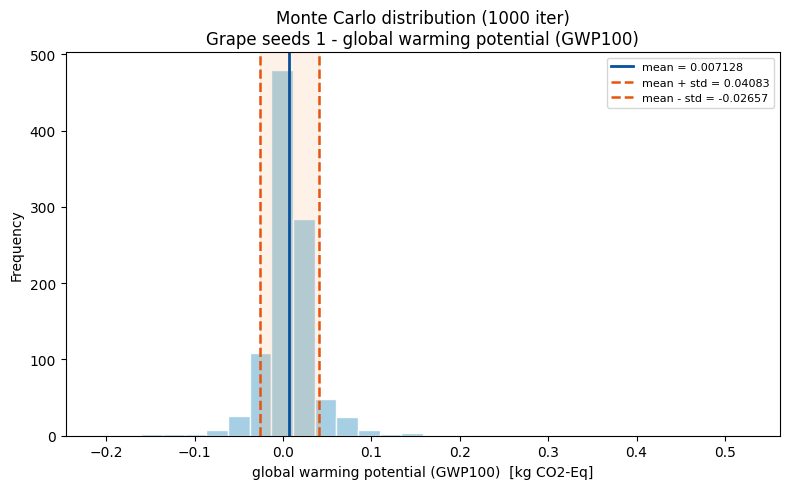

  saved: std_grape_seeds_1_global_warming_potential_gwp100.png


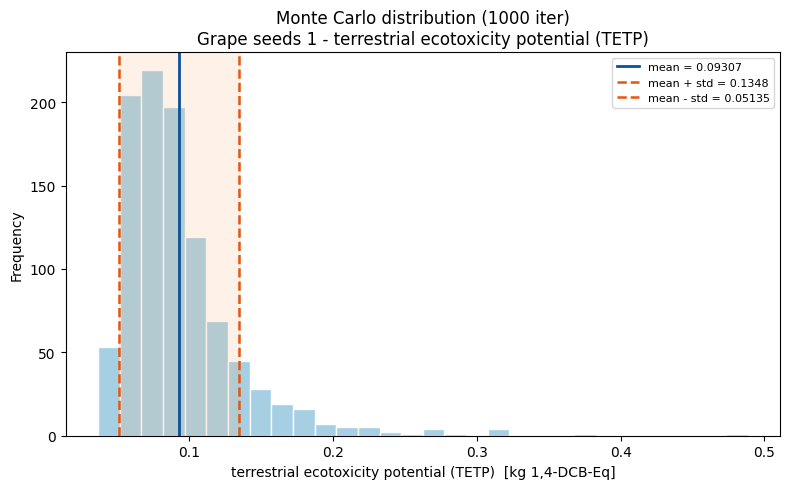

  saved: std_grape_seeds_1_terrestrial_ecotoxicity_potential_tetp.png


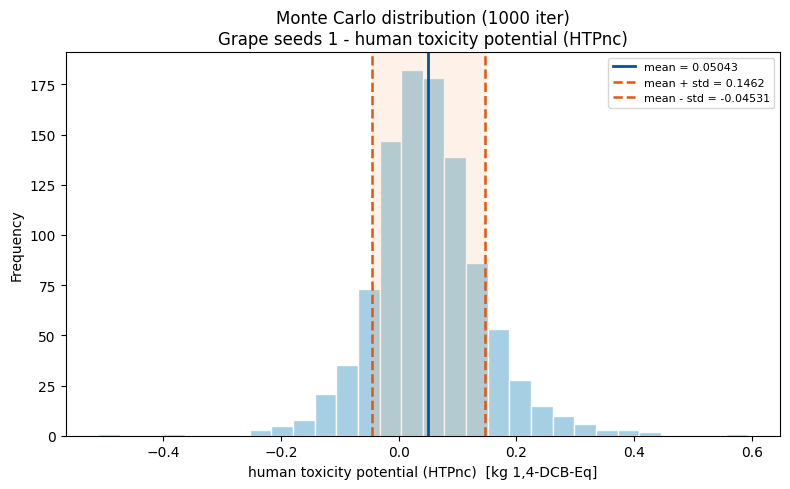

  saved: std_grape_seeds_1_human_toxicity_potential_htpnc.png


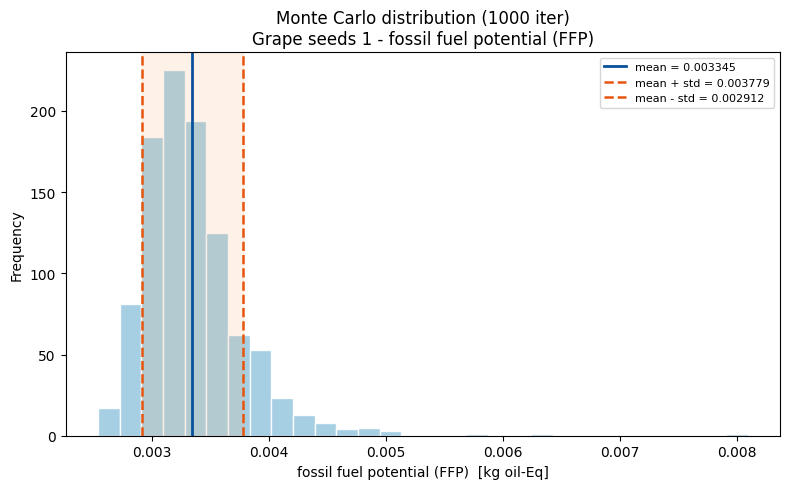

  saved: std_grape_seeds_1_fossil_fuel_potential_ffp.png


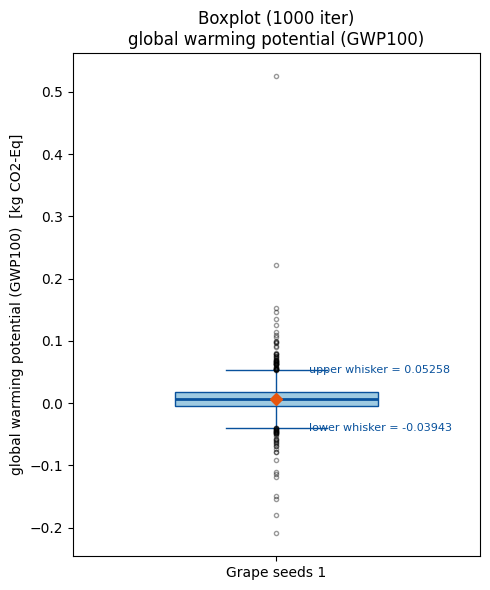

  saved: box_grape_seeds_1_global_warming_potential_gwp100.png


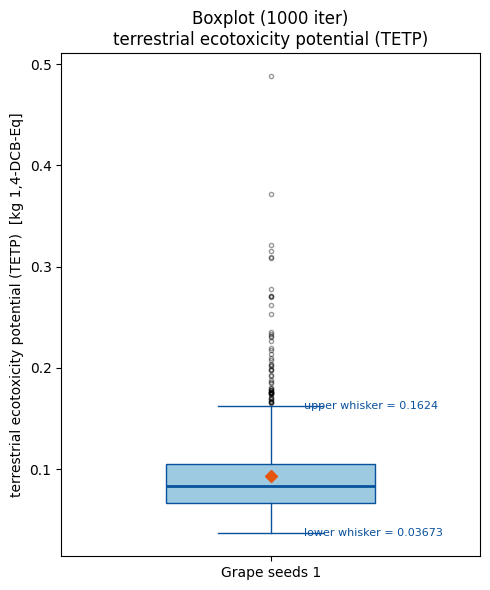

  saved: box_grape_seeds_1_terrestrial_ecotoxicity_potential_tetp.png


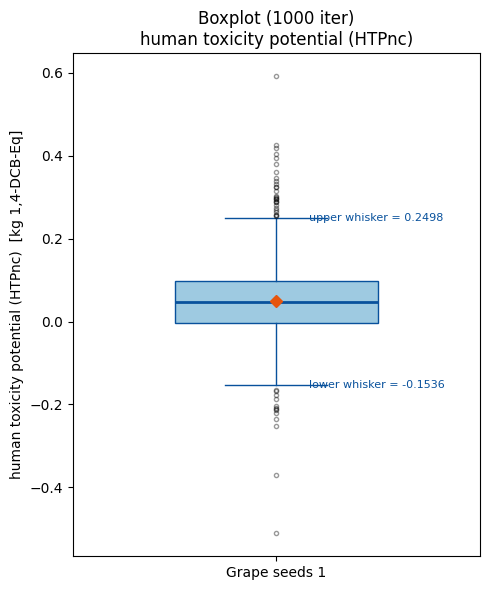

  saved: box_grape_seeds_1_human_toxicity_potential_htpnc.png


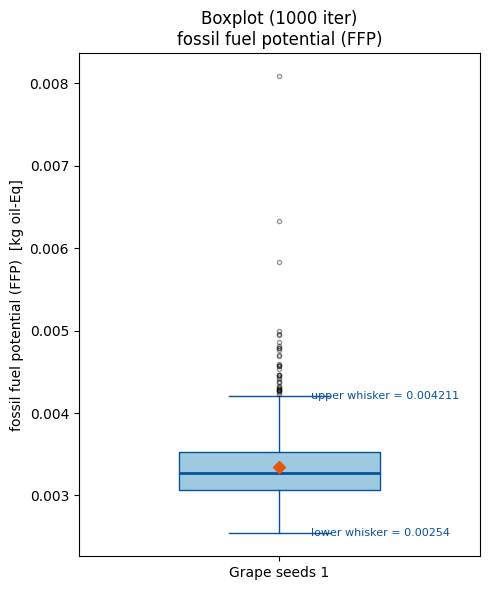

  saved: box_grape_seeds_1_fossil_fuel_potential_ffp.png

Monte Carlo Excel saved to:
  c:\Users\s233432\OneDrive - Danmarks Tekniske Universitet\Skrivebord\GREENFUEL_PROJECT\LCA_PROJECT\Project biomass\Monte_carlo_analysis\montecarlo_grape_seeds_1.xlsx
Plots + Excel stored in:
  c:\Users\s233432\OneDrive - Danmarks Tekniske Universitet\Skrivebord\GREENFUEL_PROJECT\LCA_PROJECT\Project biomass\Monte_carlo_analysis


In [135]:
# == Step 9: Monte Carlo - uncertainty analysis for the top 4 categories ======
import os, re
import matplotlib.pyplot as plt

# ---- Output folder -----------------------------------------------------------
output_dir = os.path.dirname(os.path.abspath('__file__'))
MC_DIR = os.path.join(output_dir, 'Monte_carlo_analysis')
os.makedirs(MC_DIR, exist_ok=True)

def _slug(text):
    s = re.sub(r'[^0-9a-zA-Z]+', '_', str(text).strip().lower())
    return re.sub(r'_+', '_', s).strip('_') or 'x'

top4_methods = list(top4_df.index)
print(f'Running {MC_ITERATIONS} Monte Carlo iterations across {len(top4_methods)} categories...')
print('(shared sampled inventory per iteration -> consistent and faster)\n')

# ---- One MC engine; switch characterization method each iteration ------------
mc_lca = bc.LCA({act: 1}, method=top4_methods[0], use_distributions=True)
mc_lca.lci()
mc_lca.lcia()

raw_scores = {m: [] for m in top4_methods}
for _ in tqdm(range(MC_ITERATIONS), desc='Monte Carlo'):
    next(mc_lca)                       # resample technosphere + biosphere
    for m in top4_methods:
        mc_lca.switch_method(m)        # swap characterization matrix
        mc_lca.lcia()
        raw_scores[m].append(mc_lca.score)

# ---- Summary statistics + matplotlib-style whiskers --------------------------
def whiskers(vals):
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    arr = np.asarray(vals)
    lower = arr[arr >= lo_fence].min() if np.any(arr >= lo_fence) else arr.min()
    upper = arr[arr <= hi_fence].max() if np.any(arr <= hi_fence) else arr.max()
    return q1, med, q3, lower, upper

summary_rows = []
raw_table = {}
for m in top4_methods:
    vals = np.asarray(raw_scores[m], dtype=float)
    mean, std = vals.mean(), vals.std()
    q1, med, q3, lo_w, hi_w = whiskers(vals)
    cat  = all_scores[m]['category']
    unit = all_scores[m]['unit']
    summary_rows.append({
        'biomass_type':       BIOMASS_NAME,
        'category':           cat,
        'unit':               unit,
        'deterministic_score': all_scores[m]['score'],
        'mc_mean':            mean,
        'mc_std':             std,
        'mean_plus_std':      mean + std,
        'mean_minus_std':     mean - std,
        'cv_pct':             (std / abs(mean) * 100) if mean != 0 else np.nan,
        'q1':                 q1,
        'median':             med,
        'q3':                 q3,
        'lower_whisker':      lo_w,
        'upper_whisker':      hi_w,
        'min':                vals.min(),
        'max':                vals.max(),
        'n_iterations':       len(vals),
    })
    raw_table[cat] = vals

mc_summary = pd.DataFrame(summary_rows)
print('\nMonte Carlo summary:')
print(mc_summary[['category', 'mc_mean', 'mc_std', 'mean_minus_std',
                  'mean_plus_std', 'lower_whisker', 'upper_whisker',
                  'cv_pct', 'unit']].to_string(index=False))

# Raw iterations: one column per category (for easy multi-run comparison later)
raw_df = pd.DataFrame(raw_table)
raw_df.insert(0, 'iteration', np.arange(1, MC_ITERATIONS + 1))
raw_df.insert(0, 'biomass_type', BIOMASS_NAME)

# =============================================================================
# PLOT 1 - Standard-deviation plot per category (mean, mean +/- std)
# =============================================================================
for row in summary_rows:
    cat, unit = row['category'], row['unit']
    vals = raw_table[cat]
    mean, std = row['mc_mean'], row['mc_std']

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(vals, bins=30, color='#9ecae1', edgecolor='white', alpha=0.9)
    ax.axvline(mean,       color='#08519c', lw=2.0, label=f'mean = {mean:.4g}')
    ax.axvline(mean + std, color='#e6550d', lw=1.8, ls='--', label=f'mean + std = {mean+std:.4g}')
    ax.axvline(mean - std, color='#e6550d', lw=1.8, ls='--', label=f'mean - std = {mean-std:.4g}')
    ax.axvspan(mean - std, mean + std, color='#fdae6b', alpha=0.15)
    ax.set_xlabel(f'{cat}  [{unit}]')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Monte Carlo distribution ({MC_ITERATIONS} iter)\n{BIOMASS_NAME} - {cat}')
    ax.legend(fontsize=8)
    fig.tight_layout()
    p = os.path.join(MC_DIR, f'std_{_slug(BIOMASS_NAME)}_{_slug(cat)}.png')
    fig.savefig(p, dpi=150)
    plt.show()
    plt.close(fig)
    print(f'  saved: {os.path.basename(p)}')

# =============================================================================
# PLOT 2 - Boxplot with whiskers per category
# =============================================================================
for row in summary_rows:
    cat, unit = row['category'], row['unit']
    vals = raw_table[cat]

    fig, ax = plt.subplots(figsize=(5, 6))
    bp = ax.boxplot(vals, vert=True, widths=0.5, showmeans=True,
                    patch_artist=True,
                    boxprops=dict(facecolor='#9ecae1', color='#08519c'),
                    medianprops=dict(color='#08519c', lw=2),
                    meanprops=dict(marker='D', markerfacecolor='#e6550d',
                                   markeredgecolor='#e6550d'),
                    whiskerprops=dict(color='#08519c'),
                    capprops=dict(color='#08519c'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    lo_w, hi_w = row['lower_whisker'], row['upper_whisker']
    ax.annotate(f'upper whisker = {hi_w:.4g}', xy=(1.08, hi_w),
                fontsize=8, va='center', color='#08519c')
    ax.annotate(f'lower whisker = {lo_w:.4g}', xy=(1.08, lo_w),
                fontsize=8, va='center', color='#08519c')
    ax.set_xticks([1]); ax.set_xticklabels([BIOMASS_NAME])
    ax.set_ylabel(f'{cat}  [{unit}]')
    ax.set_title(f'Boxplot ({MC_ITERATIONS} iter)\n{cat}')
    fig.tight_layout()
    p = os.path.join(MC_DIR, f'box_{_slug(BIOMASS_NAME)}_{_slug(cat)}.png')
    fig.savefig(p, dpi=150)
    plt.show()
    plt.close(fig)
    print(f'  saved: {os.path.basename(p)}')

# =============================================================================
# EXCEL - summary + combined raw + one sheet per category
# =============================================================================
xlsx_mc = os.path.join(MC_DIR, f'montecarlo_{_slug(BIOMASS_NAME)}.xlsx')
with pd.ExcelWriter(xlsx_mc, engine='openpyxl') as writer:
    mc_summary.to_excel(writer, sheet_name='Summary', index=False)
    raw_df.to_excel(writer, sheet_name='Raw_All_Categories', index=False)
    used = set()
    for cat in raw_table:
        sheet = _slug(cat)[:28]
        while sheet in used:
            sheet = sheet[:26] + '_x'
        used.add(sheet)
        one = pd.DataFrame({
            'biomass_type': BIOMASS_NAME,
            'iteration':    np.arange(1, MC_ITERATIONS + 1),
            'score':        raw_table[cat],
        })
        one.to_excel(writer, sheet_name=sheet, index=False)

print(f'\nMonte Carlo Excel saved to:\n  {xlsx_mc}')
print(f'Plots + Excel stored in:\n  {MC_DIR}')
